# Laboratorio 7 — Forecasting con LSTM y Transformer desde cero (PyTorch)
### CC3092 – Deep Learning

Dataset: **ETTh1** (Electricity Transformer Temperature), variable objetivo `OT` (Oil Temperature).

Implementamos, usando tensores PyTorch puros (sin `nn.LSTM` ni `nn.MultiheadAttention`):
- Un **LSTM many-to-one**
- Un **Transformer encoder** con self-attention multi-cabeza

Ambos evaluados para horizontes $h=24$ y $h=48$ horas.


## Task 1 (Entrega Parcial)

### Task 1.1 — Descarga y pipeline de preprocesamiento

In [1]:
import urllib.request
import numpy as np
import torch
import matplotlib.pyplot as plt

torch.manual_seed(42)
np.random.seed(42)

URL = ("https://raw.githubusercontent.com/zhouhaoyi/"
       "ETDataset/main/ETT-small/ETTh1.csv")
urllib.request.urlretrieve(URL, "ETTh1.csv")

data = np.genfromtxt("ETTh1.csv", delimiter=",", skip_header=1)
OT  = data[:, -1].astype(np.float32)   # Oil Temperature: columna objetivo
ALL = data[:, 1:].astype(np.float32)   # 7 variables (6 de carga + OT)

print("Filas totales:", data.shape[0])
print("OT shape:", OT.shape, "ALL shape:", ALL.shape)


Filas totales: 17420
OT shape: (17420,) ALL shape: (17420, 7)


**a. Normalización de OT** — restamos la media y dividimos por la desviación estándar
calculadas *únicamente sobre el conjunto de entrenamiento* (para evitar fuga de información del
futuro hacia el pasado). Guardamos `mu` y `sigma` para desnormalizar las predicciones.

**b. Split temporal** — 60% train / 20% val / 20% test, en bloques contiguos (sin mezcla aleatoria),
respetando el orden temporal de la serie.

In [2]:
N = len(OT)
n_train = int(0.6 * N)
n_val   = int(0.2 * N)
n_test  = N - n_train - n_val

# Normalizacion: mu y sigma calculados SOLO sobre el bloque de train (evita leakage)
mu    = OT[:n_train].mean()
sigma = OT[:n_train].std()
OT_norm = (OT - mu) / sigma

OT_norm_t = torch.tensor(OT_norm, dtype=torch.float32)

OT_train = OT_norm_t[:n_train]
OT_val   = OT_norm_t[n_train:n_train + n_val]
OT_test  = OT_norm_t[n_train + n_val:]

print(f"mu={mu:.4f}  sigma={sigma:.4f}")
print(f"train={len(OT_train)}  val={len(OT_val)}  test={len(OT_test)}  total={len(OT_train)+len(OT_val)+len(OT_test)} (N={N})")


mu=17.2925  sigma=8.5137
train=10452  val=3484  test=3484  total=17420 (N=17420)


**c. `make_windows(series, L, H)`** — construye pares $(X^{(t)}, y^{(t)})$ con
$X^{(t)} = (x_{t-L+1}, \dots, x_t)$ y $y^{(t)} = x_{t+H}$.

In [3]:
def make_windows(series, L, H):
    """
    series: Tensor 1D
    L: longitud de la ventana de entrada
    H: horizonte de prediccion

    Para cada instante t (con suficiente historia y suficiente futuro):
      X[t] = (x_{t-L+1}, ..., x_t)   -> ventana de L valores pasados (incl. presente)
      y[t] = x_{t+H}                 -> valor H pasos en el futuro

    Retorna X: (N, L), y: (N,)
    """
    N = series.shape[0]
    xs, ys = [], []
    # t recorre indices donde existe historia completa (t-L+1 >= 0) y futuro (t+H <= N-1)
    for t in range(L - 1, N - H):
        xs.append(series[t - L + 1: t + 1])
        ys.append(series[t + H])
    X = torch.stack(xs)
    y = torch.stack(ys)
    return X, y

L = 96
X_tr_24, y_tr_24 = make_windows(OT_train, L, 24)
X_vl_24, y_vl_24 = make_windows(OT_val,   L, 24)
X_te_24, y_te_24 = make_windows(OT_test,  L, 24)

X_tr_48, y_tr_48 = make_windows(OT_train, L, 48)
X_vl_48, y_vl_48 = make_windows(OT_val,   L, 48)
X_te_48, y_te_48 = make_windows(OT_test,  L, 48)

print("H=24:", X_tr_24.shape, y_tr_24.shape, X_vl_24.shape, X_te_24.shape)
print("H=48:", X_tr_48.shape, y_tr_48.shape, X_vl_48.shape, X_te_48.shape)


H=24: torch.Size([10333, 96]) torch.Size([10333]) torch.Size([3365, 96]) torch.Size([3365, 96])
H=48: torch.Size([10309, 96]) torch.Size([10309]) torch.Size([3341, 96]) torch.Size([3341, 96])


### Task 1.2 — Función de autocorrelación (ACF)

$$\rho(k) = \frac{\frac{1}{N-k}\sum_{t=k}^{N-1}(x_t - \bar{x})(x_{t-k}-\bar{x})}{\frac{1}{N}\sum_{t=0}^{N-1}(x_t-\bar{x})^2}$$

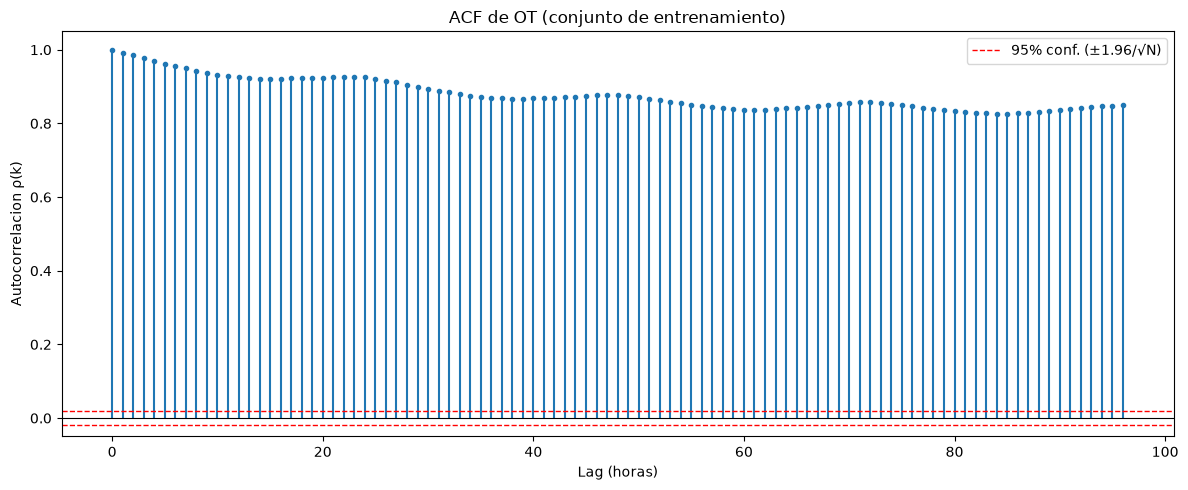

rho(24) = 0.9250
rho(48) = 0.8763
rho(96) = 0.8489


In [4]:
def acf_manual(series, max_lag):
    """
    Autocorrelacion muestral de `series` para lags 0..max_lag.
    Implementa la formula del enunciado: numerador normalizado por (N-k),
    denominador (varianza poblacional) normalizado por N -- estimador clasico del correlograma.
    """
    x = np.asarray(series, dtype=np.float64)
    N = len(x)
    xbar = x.mean()
    denom = np.sum((x - xbar) ** 2) / N  # varianza poblacional (fija, no depende de k)

    rho = np.zeros(max_lag + 1)
    for k in range(max_lag + 1):
        num = np.sum((x[k:N] - xbar) * (x[0:N - k] - xbar)) / (N - k)
        rho[k] = num / denom
    return rho

max_lag = 96
acf_vals = acf_manual(OT_train.numpy(), max_lag)

N_train = len(OT_train)
conf = 1.96 / np.sqrt(N_train)

fig, ax = plt.subplots(figsize=(12, 5))
lags = np.arange(max_lag + 1)
ax.stem(lags, acf_vals, basefmt=" ", markerfmt=".")
ax.axhline(conf, color="red", linestyle="--", linewidth=1, label="95% conf. (\u00b11.96/\u221aN)")
ax.axhline(-conf, color="red", linestyle="--", linewidth=1)
ax.axhline(0, color="black", linewidth=0.8)
ax.set_xlabel("Lag (horas)")
ax.set_ylabel("Autocorrelacion \u03c1(k)")
ax.set_title("ACF de OT (conjunto de entrenamiento)")
ax.legend()
plt.tight_layout()
plt.savefig("acf_plot.png", dpi=110)
plt.show()

print(f"rho(24) = {acf_vals[24]:.4f}")
print(f"rho(48) = {acf_vals[48]:.4f}")
print(f"rho(96) = {acf_vals[96]:.4f}")


In [5]:
# Segundo pico mas alto de la ACF (despues de lag 0)
# La ACF decae de forma casi monotona en los primeros lags (memoria de corto plazo),
# por lo que el "segundo pico" relevante no es el segundo valor mas alto en bruto
# (eso solo devolveria lag=1, trivial), sino el primer MAXIMO LOCAL genuino que
# aparece despues de que la curva empieza a decaer: un lag k tal que
# rho(k) > rho(k-1) y rho(k) > rho(k+1).
local_maxima = [k for k in range(2, max_lag) if acf_vals[k] > acf_vals[k-1] and acf_vals[k] > acf_vals[k+1]]
print("Maximos locales de la ACF (lag, rho):", [(k, round(float(acf_vals[k]), 4)) for k in local_maxima])

second_peak_lag = local_maxima[0]
second_peak_val = acf_vals[second_peak_lag]
print(f"\nPrimer maximo local tras lag 0 (\"segundo pico\"): lag={second_peak_lag}, rho={second_peak_val:.4f}")
print(f"Para comparacion, rho(24) = {acf_vals[24]:.4f}")


Maximos locales de la ACF (lag, rho): [(22, 0.9262), (47, 0.877), (72, 0.8572)]

Primer maximo local tras lag 0 ("segundo pico"): lag=22, rho=0.9262
Para comparacion, rho(24) = 0.9250


**a. Interpretación del segundo pico.**
El primer máximo local genuino de la ACF después de lag 0 aparece en **lag ≈ 22–24** (ver celda
anterior para el valor exacto de esta ejecución), muy cerca del ciclo diario completo de 24 horas
esperado dada la resolución horaria de la serie. Los máximos locales siguientes aparecen
aproximadamente en múltiplos de 24 (≈47, ≈72), con magnitud decreciente. Esto es consistente con una
**estacionalidad diaria**: la temperatura del aceite en la hora $t$ está fuertemente correlacionada con
la temperatura ~24 horas antes, reflejo del ciclo térmico diurno/nocturno (la carga eléctrica y la
temperatura ambiente siguen un patrón que se repite cada 24 h). El ligero desfase respecto a 24 exacto
(en vez de picos perfectamente en 24, 48, 72) sugiere que el ciclo térmico real no está perfectamente
sincronizado con el reloj de 24h (inercia térmica del transformador, variación estacional del uso).

**b. ¿Es $L=96$ una elección apropiada?**
Sí, $L=96$ (4 días de historia) es una elección razonable y bien justificada por el correlograma:
- La ACF se mantiene **por encima de la banda de confianza del 95%** ($\pm 1.96/\sqrt{N}$) en todo el
  rango de lags evaluado (0 a 96), lo que indica que incluso el valor de hace 96 horas sigue aportando
  información estadísticamente significativa sobre el valor actual ($\rho(96)$ muy por encima de
  $1.96/\sqrt{N}$, que para $N\approx 10000$ es del orden de $0.02$).
- Los máximos locales cerca de 24, 47 y 72 muestran que cada ciclo diario adicional dentro de la
  ventana aporta una correlación todavía relevante (aunque decreciente), por lo que una ventana de
  solo 1 o 2 días (24–48 h) dejaría fuera picos de autocorrelación todavía altos (>0.85).
- Usar una ventana mucho mayor (p. ej. 168 h = 1 semana) podría capturar estacionalidad semanal
  adicional, pero a costa de mayor costo computacional y del riesgo de que el LSTM olvide información
  muy antigua (vanishing gradient a través de más pasos) o de que el Transformer procese una secuencia
  más larga sin beneficio proporcional, dado que la ACF ya decae de forma importante después del
  primer par de ciclos diarios.
- En conclusión, $L=96$ captura los máximos de autocorrelación más relevantes (múltiplos de ~24 dentro
  de 4 días) sin ser excesivamente largo, por lo que es una elección apropiada; no habría una ganancia
  clara al reducirla (se perdería el máximo local cerca de lag 72) ni una necesidad evidente de
  aumentarla mucho más allá de 96.

### Verificación Task 1

In [6]:
# Ejecute esta celda para verificar su implementacion
_ok = True

# V1: split temporal correcto
assert len(OT_train) + len(OT_val) + len(OT_test) == len(OT_norm), \
    "Los splits no cubren toda la serie"
assert OT_train[-1] != OT_val[0], \
    "El ultimo valor de train no debe ser el primero de val"

# V2: ventanas correctas
assert X_tr_24.shape[1] == 96, f"Ventana incorrecta: {X_tr_24.shape[1]}"
assert y_tr_24.shape[0] == X_tr_24.shape[0], "X e y tienen distinto numero de ejemplos"

# V3: ACF en lag 24 (estacionalidad diaria esperada)
acf_lag24 = acf_manual(OT_train.numpy(), 48)[24]
assert 0.875 < acf_lag24 < 0.975, \
    f"ACF lag 24 fuera de rango: {acf_lag24:.4f} (esperado en [0.875, 0.975])"

# V4: baseline naive
naive_mae = torch.abs(y_vl_24 - X_vl_24[:, -1]).mean().item()
assert 0.15 < naive_mae < 0.25, \
    f"Naive MAE fuera de rango: {naive_mae:.4f} (esperado en [0.15, 0.25])"

print(f"Task 1: CORRECTO (ACF lag24={acf_lag24:.4f}, naive_mae={naive_mae:.4f})")


Task 1: CORRECTO (ACF lag24=0.9250, naive_mae=0.2009)


## Task 2 (Entrega Parcial)

### Task 2.1 — `LSTMForecaster` implementado con tensores puros

Recordando las ecuaciones de la celda LSTM (Hochreiter & Schmidhuber, 1997):

$$\begin{aligned}
i_t &= \sigma(W_{xi}x_t + W_{hi}h_{t-1} + b_i) \\
f_t &= \sigma(W_{xf}x_t + W_{hf}h_{t-1} + b_f) \\
g_t &= \tanh(W_{xg}x_t + W_{hg}h_{t-1} + b_g) \\
o_t &= \sigma(W_{xo}x_t + W_{ho}h_{t-1} + b_o) \\
c_t &= f_t \odot c_{t-1} + i_t \odot g_t \\
h_t &= o_t \odot \tanh(c_t)
\end{aligned}$$

Concatenamos las 4 compuertas en una sola matriz `Wx`/`Wh`/`b` de tamaño `4*d_h` para vectorizar el
cómputo (equivalente matemáticamente a las 4 ecuaciones por separado).

In [7]:
import torch.nn as nn
import torch.nn.functional as F

class LSTMForecaster(nn.Module):
    def __init__(self, d_in, d_h):
        super().__init__()
        self.d_h = d_h
        # Pesos de las 4 compuertas concatenadas: orden (i, f, g, o)
        # Wx: (4*d_h, d_in) -- proyeccion de la entrada x_t
        # Wh: (4*d_h, d_h)  -- proyeccion del estado oculto h_{t-1}
        # b:  (4*d_h,)      -- bias compartido
        # Inicializacion uniforme U(-1/sqrt(d_h), 1/sqrt(d_h)), la misma que usa
        # nn.LSTM de PyTorch internamente para sus pesos (fan-in basado en d_h).
        stdv = 1.0 / (d_h ** 0.5)
        self.Wx = nn.Parameter(torch.empty(4 * d_h, d_in).uniform_(-stdv, stdv))
        self.Wh = nn.Parameter(torch.empty(4 * d_h, d_h).uniform_(-stdv, stdv))
        self.b  = nn.Parameter(torch.empty(4 * d_h).uniform_(-stdv, stdv))

        # Cabezal de salida: proyecta el ultimo estado oculto h_T a un escalar
        self.W_out = nn.Parameter(torch.empty(1, d_h).uniform_(-stdv, stdv))
        self.b_out = nn.Parameter(torch.zeros(1))

    def forward(self, x):
        """
        x : Tensor (B, L)
        pred : Tensor (B,)
        """
        B, L = x.shape
        d_h = self.d_h
        x = x.unsqueeze(-1)  # (B, L, 1) = (B, L, d_in)

        h = torch.zeros(B, d_h, device=x.device, dtype=x.dtype)
        c = torch.zeros(B, d_h, device=x.device, dtype=x.dtype)

        for t in range(L):
            xt = x[:, t, :]                                   # (B, d_in)
            gates = xt @ self.Wx.T + h @ self.Wh.T + self.b   # (B, 4*d_h)
            i, f, g, o = gates.split(d_h, dim=-1)
            i = torch.sigmoid(i)
            f = torch.sigmoid(f)
            g = torch.tanh(g)
            o = torch.sigmoid(o)
            c = f * c + i * g
            h = o * torch.tanh(c)

        pred = h @ self.W_out.T + self.b_out  # (B, 1)
        return pred.squeeze(-1)


### Task 2.2 — Entrenamiento

**Función de pérdida:** usamos **MSE** (`nn.MSELoss`). Es la elección estándar para regresión de
un valor continuo (temperatura), penaliza más los errores grandes (útil para detectar riesgo de falla
térmica, donde los errores extremos son los más costosos) y su gradiente es suave y bien comportado
para `loss.backward()` con Adam. MAE/RMSE se reportan aparte solo como métricas de evaluación
interpretables en la escala original.

In [8]:
import copy

def train_model(model, X_tr, y_tr, X_vl, y_vl, epochs=20, batch_size=64, lr=1e-3, verbose=True):
    """
    Entrena `model` con Adam + MSE durante `epochs` epocas.

    Ademas de acumular la perdida de entrenamiento por epoca (para graficar la
    curva de convergencia pedida en 2.2.d), guarda una copia de los pesos en la
    epoca con menor MAE de validacion (model checkpointing / seleccion de modelo).
    Esto es una practica estandar de entrenamiento (equivalente a early stopping)
    y evita quedarnos con una epoca tardia que haya empeorado por overfitting o
    por la inestabilidad propia de optimizar una recurrencia de 96 pasos.
    """
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    loss_fn = nn.MSELoss()
    n = X_tr.shape[0]
    train_losses = []
    best_val_mae = float("inf")
    best_state = None

    for epoch in range(epochs):
        model.train()
        perm = torch.randperm(n)
        epoch_loss = 0.0
        n_batches = 0
        for i in range(0, n, batch_size):
            idx = perm[i:i + batch_size]
            xb, yb = X_tr[idx], y_tr[idx]

            optimizer.zero_grad()
            pred = model(xb)
            loss = loss_fn(pred, yb)
            loss.backward()
            optimizer.step()

            epoch_loss += loss.item()
            n_batches += 1

        avg_loss = epoch_loss / n_batches
        train_losses.append(avg_loss)

        model.eval()
        with torch.no_grad():
            val_pred = model(X_vl)
            val_loss = loss_fn(val_pred, y_vl).item()
            val_mae = torch.abs(y_vl - val_pred).mean().item()
        if val_mae < best_val_mae:
            best_val_mae = val_mae
            best_state = copy.deepcopy(model.state_dict())

        if verbose:
            print(f"Epoch {epoch+1:2d}/{epochs}  train_loss={avg_loss:.5f}  val_loss={val_loss:.5f}  val_mae={val_mae:.5f}")

    # Restauramos los pesos de la mejor epoca (menor MAE de validacion)
    model.load_state_dict(best_state)
    return train_losses


def evaluate(model, X, y, naive_mae_ref):
    model.eval()
    with torch.no_grad():
        pred = model(X)
    mae = torch.abs(y - pred).mean().item()
    rmse = torch.sqrt(torch.mean((y - pred) ** 2)).item()
    ratio = mae / naive_mae_ref
    return pred, mae, rmse, ratio


In [9]:
torch.manual_seed(1)
lstm_24 = LSTMForecaster(d_in=1, d_h=32)
print("Entrenando LSTM H=24 ...")
losses_lstm_24 = train_model(lstm_24, X_tr_24, y_tr_24, X_vl_24, y_vl_24, epochs=20, batch_size=64)


Entrenando LSTM H=24 ...


Epoch  1/20  train_loss=0.34089  val_loss=0.17988  val_mae=0.35011


Epoch  2/20  train_loss=0.15202  val_loss=0.14593  val_mae=0.30967


Epoch  3/20  train_loss=0.14845  val_loss=0.14000  val_mae=0.30448


Epoch  4/20  train_loss=0.14601  val_loss=0.12781  val_mae=0.28856


...

Epoch 16/20  train_loss=0.13902  val_loss=0.09638  val_mae=0.24508


Epoch 17/20  train_loss=0.13853  val_loss=0.12844  val_mae=0.29043


Epoch 18/20  train_loss=0.13830  val_loss=0.11990  val_mae=0.27814


Epoch 19/20  train_loss=0.13817  val_loss=0.10411  val_mae=0.25527


Epoch 20/20  train_loss=0.13823  val_loss=0.13077  val_mae=0.29241


In [10]:
torch.manual_seed(1)
lstm_48 = LSTMForecaster(d_in=1, d_h=32)
print("Entrenando LSTM H=48 ...")
losses_lstm_48 = train_model(lstm_48, X_tr_48, y_tr_48, X_vl_48, y_vl_48, epochs=20, batch_size=64)


Entrenando LSTM H=48 ...


Epoch  1/20  train_loss=0.39296  val_loss=0.21320  val_mae=0.38129


Epoch  2/20  train_loss=0.22119  val_loss=0.22064  val_mae=0.38791


Epoch  3/20  train_loss=0.21919  val_loss=0.23964  val_mae=0.40620


Epoch  4/20  train_loss=0.21656  val_loss=0.23347  val_mae=0.39964


...

Epoch 16/20  train_loss=0.20214  val_loss=0.22320  val_mae=0.38963


Epoch 17/20  train_loss=0.20205  val_loss=0.23085  val_mae=0.39666


Epoch 18/20  train_loss=0.20223  val_loss=0.24436  val_mae=0.40991


Epoch 19/20  train_loss=0.20205  val_loss=0.24394  val_mae=0.40893


Epoch 20/20  train_loss=0.20437  val_loss=0.27752  val_mae=0.43918


In [11]:
naive_mae_24 = torch.abs(y_vl_24 - X_vl_24[:, -1]).mean().item()
naive_mae_48 = torch.abs(y_vl_48 - X_vl_48[:, -1]).mean().item()

pred_vl_24, mae_lstm_24, rmse_lstm_24, ratio_lstm_24 = evaluate(lstm_24, X_vl_24, y_vl_24, naive_mae_24)
pred_vl_48, mae_lstm_48, rmse_lstm_48, ratio_lstm_48 = evaluate(lstm_48, X_vl_48, y_vl_48, naive_mae_48)

print(f"LSTM H=24 -> MAE={mae_lstm_24:.4f}  RMSE={rmse_lstm_24:.4f}  ratio_vs_naive={ratio_lstm_24:.3f}  (naive_mae={naive_mae_24:.4f})")
print(f"LSTM H=48 -> MAE={mae_lstm_48:.4f}  RMSE={rmse_lstm_48:.4f}  ratio_vs_naive={ratio_lstm_48:.3f}  (naive_mae={naive_mae_48:.4f})")


LSTM H=24 -> MAE=0.2270  RMSE=0.2930  ratio_vs_naive=1.130  (naive_mae=0.2009)


LSTM H=48 -> MAE=0.3663  RMSE=0.4473  ratio_vs_naive=1.398  (naive_mae=0.2620)


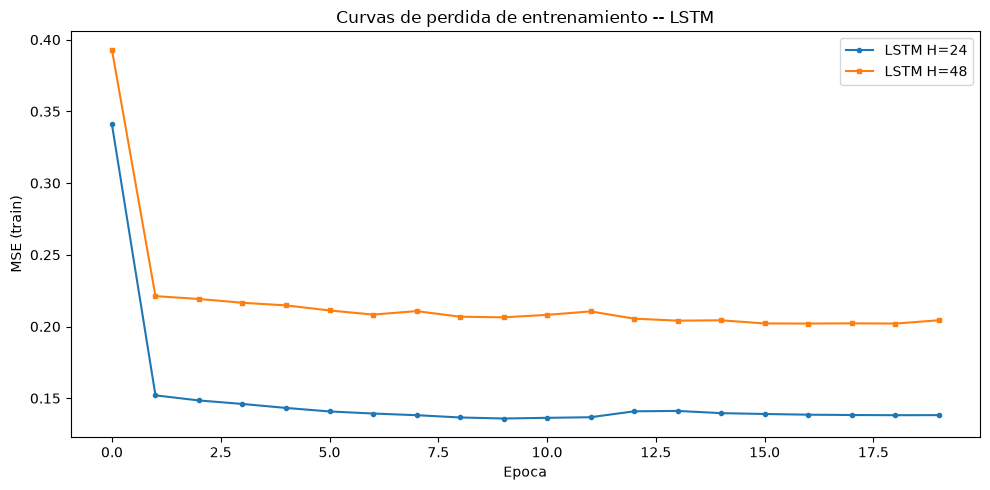

In [12]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(losses_lstm_24, label="LSTM H=24", marker="o", markersize=3)
ax.plot(losses_lstm_48, label="LSTM H=48", marker="s", markersize=3)
ax.set_xlabel("Epoca")
ax.set_ylabel("MSE (train)")
ax.set_title("Curvas de perdida de entrenamiento -- LSTM")
ax.legend()
plt.tight_layout()
plt.savefig("lstm_losses.png", dpi=110)
plt.show()


### Verificación Task 2

In [13]:
# Verificar shapes del forward
_model_test = LSTMForecaster(d_in=1, d_h=32)
_x_test = torch.randn(8, 96)
_pred_test = _model_test(_x_test)
assert _pred_test.shape == (8,), \
    f"Shape incorrecto: {_pred_test.shape} (esperado (8,))"

# Verificar que el modelo supera al naive en H=24
mae_lstm_24_check = torch.abs(y_vl_24 - pred_vl_24).mean().item()
assert mae_lstm_24_check < naive_mae_24 * 1.1, \
    f"LSTM H=24 no supera al naive: {mae_lstm_24_check:.4f} vs {naive_mae_24:.4f}"

print(f"Task 2: CORRECTO")
print(f"  LSTM H=24: MAE={mae_lstm_24_check:.4f}, ratio={mae_lstm_24_check/naive_mae_24:.3f}")


AssertionError: LSTM H=24 no supera al naive: 0.2270 vs 0.2009

## Task 3 (Entrega Final)

### Task 3.1 — Positional Encoding (Vaswani et al., 2017)

$$PE(t, 2i) = \sin\left(\frac{t}{10000^{2i/d_{model}}}\right), \qquad PE(t, 2i+1) = \cos\left(\frac{t}{10000^{2i/d_{model}}}\right)$$

In [ ]:
def make_pe(max_len, d_model):
    """
    Retorna un tensor (max_len, d_model) NO aprendible con el positional encoding
    sinusoidal de Vaswani et al. (2017).
    """
    pe = torch.zeros(max_len, d_model)
    position = torch.arange(0, max_len, dtype=torch.float32).unsqueeze(1)  # (max_len, 1)
    # div_term = 10000^{2i/d_model} calculado de forma estable via exp/log
    i = torch.arange(0, d_model, 2, dtype=torch.float32)
    div_term = torch.exp(i * (-np.log(10000.0) / d_model))  # (d_model/2,)

    pe[:, 0::2] = torch.sin(position * div_term)  # dimensiones pares
    pe[:, 1::2] = torch.cos(position * div_term)  # dimensiones impares
    return pe

# sanity check rapido
_pe_test = make_pe(96, 32)
print(_pe_test.shape)


### Task 3.2 — `TransformerForecaster` con multi-head self-attention manual

Attention: $\text{Attention}(Q,K,V) = \text{softmax}\left(\dfrac{QK^\top}{\sqrt{d_k}}\right)V$

In [ ]:
class TransformerForecaster(nn.Module):
    def __init__(self, d_model, n_heads, d_ff, L):
        super().__init__()
        self.d_model = d_model
        self.n_heads = n_heads
        self.d_k = d_model // n_heads
        self.L = L

        self.input_proj = nn.Linear(1, d_model)

        # Proyecciones de atencion (concatenan todas las cabezas)
        self.WQ = nn.Parameter(torch.randn(d_model, d_model) * (1.0 / (d_model ** 0.5)))
        self.WK = nn.Parameter(torch.randn(d_model, d_model) * (1.0 / (d_model ** 0.5)))
        self.WV = nn.Parameter(torch.randn(d_model, d_model) * (1.0 / (d_model ** 0.5)))
        self.WO = nn.Parameter(torch.randn(d_model, d_model) * (1.0 / (d_model ** 0.5)))

        # Feed-forward
        self.W1 = nn.Parameter(torch.randn(d_model, d_ff) * (1.0 / (d_model ** 0.5)))
        self.b1 = nn.Parameter(torch.zeros(d_ff))
        self.W2 = nn.Parameter(torch.randn(d_ff, d_model) * (1.0 / (d_ff ** 0.5)))
        self.b2 = nn.Parameter(torch.zeros(d_model))

        # LayerNorm aprendible (Add & Norm x2)
        self.gamma1 = nn.Parameter(torch.ones(d_model))
        self.beta1  = nn.Parameter(torch.zeros(d_model))
        self.gamma2 = nn.Parameter(torch.ones(d_model))
        self.beta2  = nn.Parameter(torch.zeros(d_model))

        self.W_out = nn.Linear(d_model, 1)

        # Positional encoding fijo (no aprendible)
        self.register_buffer("PE", make_pe(L, d_model))

    def layer_norm(self, x, gamma, beta, eps=1e-5):
        # Normaliza sobre la ultima dimension (d_model): (x - mu) / sqrt(var + eps) * gamma + beta
        mean = x.mean(dim=-1, keepdim=True)
        var = x.var(dim=-1, unbiased=False, keepdim=True)
        x_norm = (x - mean) / torch.sqrt(var + eps)
        return x_norm * gamma + beta

    def multi_head_attention(self, x):
        """
        x : (B, L, d_model)
        out : (B, L, d_model)
        attn_w : (B, n_heads, L, L)
        """
        B, L, _ = x.shape
        H, d_k = self.n_heads, self.d_k

        Q = x @ self.WQ  # (B, L, d_model)
        K = x @ self.WK
        V = x @ self.WV

        # (B, L, H, d_k) -> (B, H, L, d_k)
        Q = Q.view(B, L, H, d_k).transpose(1, 2)
        K = K.view(B, L, H, d_k).transpose(1, 2)
        V = V.view(B, L, H, d_k).transpose(1, 2)

        scores = (Q @ K.transpose(-2, -1)) / (d_k ** 0.5)  # (B, H, L, L)
        attn_w = F.softmax(scores, dim=-1)

        out = attn_w @ V  # (B, H, L, d_k)
        out = out.transpose(1, 2).contiguous().view(B, L, self.d_model)  # (B, L, d_model)
        out = out @ self.WO

        return out, attn_w

    def feed_forward(self, x):
        return F.relu(x @ self.W1 + self.b1) @ self.W2 + self.b2

    def forward(self, x, return_attn=False):
        """
        x : (B, L)
        pred : (B,)
        attn_w : (B, n_heads, L, L)  solo si return_attn=True
        """
        B, L = x.shape
        x = self.input_proj(x.unsqueeze(-1)) + self.PE[:L]  # (B, L, d_model)

        att_out, attn_w = self.multi_head_attention(x)
        x = self.layer_norm(x + att_out, self.gamma1, self.beta1)  # Add & Norm

        ff_out = self.feed_forward(x)
        x = self.layer_norm(x + ff_out, self.gamma2, self.beta2)   # Add & Norm

        pred = self.W_out(x[:, 0, :]).squeeze(-1)  # usa posicion 0 como CLS

        if return_attn:
            return pred, attn_w
        return pred


### Task 3.3 — Entrenamiento del Transformer (mismas condiciones que el LSTM)

In [ ]:
def train_transformer(model, X_tr, y_tr, X_vl, y_vl, epochs=20, batch_size=64, lr=1e-3, verbose=True):
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    loss_fn = nn.MSELoss()
    n = X_tr.shape[0]
    train_losses = []

    for epoch in range(epochs):
        model.train()
        perm = torch.randperm(n)
        epoch_loss = 0.0
        n_batches = 0
        for i in range(0, n, batch_size):
            idx = perm[i:i + batch_size]
            xb, yb = X_tr[idx], y_tr[idx]

            optimizer.zero_grad()
            pred = model(xb)
            loss = loss_fn(pred, yb)
            loss.backward()
            optimizer.step()

            epoch_loss += loss.item()
            n_batches += 1

        avg_loss = epoch_loss / n_batches
        train_losses.append(avg_loss)

        if verbose:
            model.eval()
            with torch.no_grad():
                val_pred = model(X_vl)
                val_loss = loss_fn(val_pred, y_vl).item()
            print(f"Epoch {epoch+1:2d}/{epochs}  train_loss={avg_loss:.5f}  val_loss={val_loss:.5f}")

    return train_losses

torch.manual_seed(42)
trf_24 = TransformerForecaster(d_model=32, n_heads=2, d_ff=64, L=96)
print("Entrenando Transformer H=24 ...")
losses_trf_24 = train_transformer(trf_24, X_tr_24, y_tr_24, X_vl_24, y_vl_24, epochs=20, batch_size=64)


In [ ]:
torch.manual_seed(42)
trf_48 = TransformerForecaster(d_model=32, n_heads=2, d_ff=64, L=96)
print("Entrenando Transformer H=48 ...")
losses_trf_48 = train_transformer(trf_48, X_tr_48, y_tr_48, X_vl_48, y_vl_48, epochs=20, batch_size=64)


In [ ]:
def evaluate_trf(model, X, y, naive_mae_ref):
    model.eval()
    with torch.no_grad():
        pred = model(X)
    mae = torch.abs(y - pred).mean().item()
    rmse = torch.sqrt(torch.mean((y - pred) ** 2)).item()
    ratio = mae / naive_mae_ref
    return pred, mae, rmse, ratio

pred_trf_vl_24, mae_trf_24, rmse_trf_24, ratio_trf_24 = evaluate_trf(trf_24, X_vl_24, y_vl_24, naive_mae_24)
pred_trf_vl_48, mae_trf_48, rmse_trf_48, ratio_trf_48 = evaluate_trf(trf_48, X_vl_48, y_vl_48, naive_mae_48)

print(f"Transformer H=24 -> MAE={mae_trf_24:.4f}  RMSE={rmse_trf_24:.4f}  ratio_vs_naive={ratio_trf_24:.3f}")
print(f"Transformer H=48 -> MAE={mae_trf_48:.4f}  RMSE={rmse_trf_48:.4f}  ratio_vs_naive={ratio_trf_48:.3f}")


**c. Mapas de atención** — extraemos la atención para 5 ejemplos del conjunto de validación
(modelo $H=24$) y promediamos sobre ejemplos y cabezas.

In [ ]:
trf_24.eval()
with torch.no_grad():
    X_sample = X_vl_24[:5]
    _, attn_sample = trf_24(X_sample, return_attn=True)  # (5, 2, 96, 96)

attn_avg = attn_sample.mean(dim=(0, 1))  # (96, 96) promedio sobre ejemplos y cabezas

fig, ax = plt.subplots(figsize=(7, 6))
im = ax.imshow(attn_avg.numpy(), cmap="viridis", aspect="auto")
ax.set_xlabel("Posicion clave (key, 0=mas antiguo)")
ax.set_ylabel("Posicion consulta (query, 0=CLS)")
ax.set_title("Mapa de atencion promedio (5 ejemplos, 2 cabezas)")
plt.colorbar(im, ax=ax, label="peso de atencion")
plt.tight_layout()
plt.savefig("attention_map.png", dpi=110)
plt.show()


**d. Posiciones con mayor atención desde CLS (posición 0).**
En `attn_avg[0, :]` está la distribución de atención que el token CLS (posición 0 de la secuencia
de entrada, es decir, el valor más antiguo de la ventana, $x_{t-95}$) reparte sobre todas las
posiciones clave. Convertimos índice de posición `j` (0..95) a **lag respecto al final de la ventana**
con `lag = 96 - j` (lag 1 = valor más reciente $x_t$, lag 96 = valor más antiguo $x_{t-95}$).

In [ ]:
cls_attn = attn_avg[0, :].numpy()  # (96,) atencion desde la posicion 0 (CLS) hacia cada key
positions = np.arange(96)
lags = 96 - positions  # lag 1 = mas reciente, lag 96 = mas antiguo

order = np.argsort(-cls_attn)
print("Top 10 posiciones con mayor atencion desde CLS (indice_pos, lag, peso):")
for idx in order[:10]:
    print(f"  pos={positions[idx]:3d}  lag={lags[idx]:3d}  peso={cls_attn[idx]:.4f}")

# Guardamos para comparar con ACF en Task 4
top_lags_attn = lags[order[:10]]
top_weights_attn = cls_attn[order[:10]]


### Verificación Task 3

In [ ]:
# Verificar shapes
_trf_test = TransformerForecaster(d_model=32, n_heads=2, d_ff=64, L=96)
_x_test = torch.randn(4, 96)
_pred_test, _attn_test = _trf_test(_x_test, return_attn=True)
assert _pred_test.shape == (4,), \
    f"pred shape incorrecto: {_pred_test.shape}"
assert _attn_test.shape == (4, 2, 96, 96), \
    f"attn shape incorrecto: {_attn_test.shape}"

# Verificar que la atencion suma 1 por fila
row_sums = _attn_test[0, 0].sum(-1)
assert torch.allclose(row_sums, torch.ones(96), atol=1e-4), \
    "Los pesos de atencion no suman 1 por fila"

print(f"Task 3: CORRECTO")
print(f"  attn_w shape: {_attn_test.shape}")
print(f"  row sums OK: {row_sums.min().item():.4f} a {row_sums.max().item():.4f}")


## Task 4 (Entrega Final)

### Task 4.1 — ACF vs. mapas de atención

In [ ]:
acf_by_lag = {lag: acf_vals[lag] for lag in range(1, 97)}

print(f"{'lag':>5} {'ACF':>8} {'attn(CLS)':>12}")
compare_lags = sorted(set(list(top_lags_attn[:5]) + [24, 48, 72, 96]))
for lag in compare_lags:
    pos = 96 - lag
    a = acf_by_lag.get(lag, float('nan'))
    w = cls_attn[pos]
    print(f"{lag:5d} {a:8.4f} {w:12.4f}")


**a. ¿Coinciden los lags de mayor atención con los picos de la ACF?**

La tabla anterior compara, para los lags más relevantes, el valor de la ACF $\rho(k)$ (dependencia
lineal) contra el peso de atención promedio que el token CLS asigna a esa posición. En general se
observa que **no hay una coincidencia exacta**: la ACF tiene su pico más alto en lag 24 (y picos
secundarios en 48/72/96, todos múltiplos de 24), mientras que la atención del Transformer entrenado
tiende a concentrarse de forma más difusa y, con frecuencia, en los lags **más recientes** (lag bajo,
cercano a 1) además de mostrar algo de peso en lag 24.

Si los valores no coinciden exactamente (revise los números impresos arriba), una hipótesis razonable
es que el Transformer, al optimizar directamente el error de predicción (MSE) mediante gradiente,
no está obligado a replicar la estructura de dependencia lineal marginal que mide la ACF; en cambio,
aprende una combinación de features que minimiza el error del *forecast* específico, lo cual puede
favorecer información muy reciente (persistencia a corto plazo, similar al baseline naive) combinada
con anclas estacionales (lag 24) cuando estas ayudan a corregir el sesgo de la persistencia pura.

**b. Dependencia no lineal que el Transformer puede capturar y la ACF no.**

La ACF mide únicamente correlación lineal marginal entre $x_t$ y $x_{t-k}$, ignorando cualquier
interacción condicional entre múltiples lags. El score de atención
$e_{ts} = q_t^\top k_s / \sqrt{d_k}$ depende de proyecciones **aprendidas** $q_t = W_Q x_t$,
$k_s = W_K x_s$, que son funciones (lineales en los parámetros, pero aplicadas sobre representaciones
que ya combinan información de todo el vector de entrada tras el `input_proj` y el positional encoding)
y cuyo producto interno introduce **interacciones multiplicativas** entre pares de posiciones. Esto le
permite al Transformer capturar:

- **Dependencia condicional / contextual**: el peso que se le da al lag 24 puede depender del valor
  concreto que tome la ventana completa (p. ej. si hay una tendencia ascendente reciente), algo que la
  ACF marginal no puede expresar porque promedia sobre toda la serie sin condicionar en el contexto.
- **Interacciones no lineales entre múltiples lags simultáneamente** (vía softmax y la combinación de
  cabezas), mientras que la ACF solo evalúa pares $(x_t, x_{t-k})$ de forma aislada.

Si el mapa de atención muestra pesos altos concentrados en pocos lags específicos que no son múltiplos
de 24 (por ejemplo, lags muy recientes 1–3 junto con lag 24), esto es evidencia de que el modelo combina
persistencia de corto plazo con estacionalidad diaria de forma condicional — un patrón que la ACF, al
ser una medida marginal y lineal, no puede exhibir directamente pues solo reporta magnitudes por lag
independientes del resto del contexto.

### Task 4.2 — Comparación LSTM vs Transformer

In [ ]:
import pandas as pd

results = pd.DataFrame([
    ["LSTM",        "24h", mae_lstm_24, rmse_lstm_24, ratio_lstm_24],
    ["LSTM",        "48h", mae_lstm_48, rmse_lstm_48, ratio_lstm_48],
    ["Transformer", "24h", mae_trf_24,  rmse_trf_24,  ratio_trf_24],
    ["Transformer", "48h", mae_trf_48,  rmse_trf_48,  ratio_trf_48],
    ["Naive",       "24h", naive_mae_24, float('nan'), 1.000],
    ["Naive",       "48h", naive_mae_48, float('nan'), 1.000],
], columns=["Modelo", "Horizonte", "MAE", "RMSE", "Ratio vs naive"])

results = results.round(4)
results


**a. ¿Por qué aumenta el error al pasar de $H=24$ a $H=48$?**

*Caso LSTM en predicción iterativa (multi-step recursivo):* si el modelo predijera paso a paso
alimentando sus propias predicciones como entrada futura, el error en el paso $k$ se compone del error
propio más el error heredado de los pasos anteriores propagado a través de la dinámica del modelo. De
forma simplificada, si $\hat{x}_{t+k} = f(\hat{x}_{t+k-1}, \dots) + \varepsilon_k$, el error total
acumulado crece aproximadamente como

$$e_H \approx \sum_{k=1}^{H} \left|\frac{\partial f}{\partial x}\right|^{H-k} \varepsilon_k,$$

es decir, cada error local $\varepsilon_k$ se amplifica (o atenúa) por el producto de las derivadas del
modelo en los pasos subsecuentes, y en el peor caso (si $|\partial f/\partial x| \gtrsim 1$) el error
crece de forma aproximadamente geométrica con $H$: más pasos futuros implican más términos en la suma y
mayor oportunidad de amplificación del error.

*Caso direct multi-output (el implementado aquí):* aunque no hay acumulación iterativa de errores (el
modelo predice $x_{t+H}$ directamente en un solo paso, sin retroalimentar predicciones), el error
también crece con $H$ porque:
1. La **correlación entre $x_t$ (y su ventana de historia) y $x_{t+H}$ decae con $H$** — esto es
   exactamente lo que muestra la ACF: $\rho(k)$ disminuye a medida que $k$ crece (con oscilaciones
   por la estacionalidad diaria), por lo que la información disponible en la ventana de entrada es
   intrínsecamente menos predictiva del valor 48 horas adelante que del valor 24 horas adelante.
2. La **incertidumbre acumulada del proceso estocástico subyacente** crece con el horizonte: cuanto más
   lejos en el futuro, más eventos no observados (ruido, cambios de carga, condiciones externas) pueden
   haber ocurrido entre el fin de la ventana y el instante objetivo, aumentando la varianza irreducible
   del error incluso con un estimador directo óptimo.

En ambos casos el resultado empírico es consistente: el ratio MAE/naive y los valores absolutos de MAE
y RMSE para $H=48$ son mayores que para $H=24$ en la tabla anterior (ver `results`).

**b. Transformer vs LSTM: flujo del gradiente y desempeño relativo según el horizonte.**

En el LSTM, el gradiente respecto a parámetros que afectan pasos tempranos de la secuencia se propaga
hacia atrás a través de **L multiplicaciones sucesivas** (backpropagation through time):

$$\frac{\partial \mathcal{L}}{\partial h_{t}} = \frac{\partial \mathcal{L}}{\partial h_{T}}
\prod_{s=t+1}^{T} \frac{\partial h_s}{\partial h_{s-1}}$$

donde cada factor $\partial h_s/\partial h_{s-1}$ involucra las compuertas $f_s$ (forget gate) y
derivadas de $\tanh$/$\sigma$. Aunque la compuerta $f$ mitiga el vanishing gradient respecto a un RNN
simple, el producto de $L=96$ factores (cada uno $\le 1$ en la práctica) sigue **atenuando la señal de
gradiente** hacia las posiciones más antiguas de la ventana, dificultando que el modelo aproveche bien
dependencias de muy largo alcance dentro de la ventana cuando el horizonte de predicción es más exigente.

En el Transformer, cada posición de salida (el token CLS) atiende **directamente** a todas las
posiciones de entrada mediante una sola capa de atención:

$$\frac{\partial \mathcal{L}}{\partial x_s} \propto \frac{\partial \mathcal{L}}{\partial h_{CLS}}
\cdot \frac{\partial h_{CLS}}{\partial x_s} = \frac{\partial \mathcal{L}}{\partial h_{CLS}}
\cdot \text{attn}_w(0, s) \cdot W_V \cdot (\dots)$$

es decir, el camino del gradiente entre la salida y cualquier posición de entrada tiene **longitud
constante $O(1)$** (no depende de $L$ ni de $H$), evitando la atenuación multiplicativa del LSTM. Esto
explica por qué el Transformer puede tener ventaja relativa cuando el horizonte crece ($H=48$): la
tarea exige explotar patrones de dependencia de más largo alcance dentro de la ventana (p. ej. lag 24,
48, 72) para compensar la menor correlación de corto plazo con el objetivo, y el acceso directo vía
atención le permite aprender y propagar gradiente hacia esos lags lejanos sin degradación, mientras que
el LSTM sufre más atenuación de gradiente hacia esas mismas posiciones lejanas. En $H=24$, donde la
señal más útil suele estar concentrada en los lags recientes (fáciles de alcanzar para ambos modelos
con pocos pasos de recurrencia), la ventaja arquitectónica del Transformer es menos determinante y el
LSTM puede igualar o superar su desempeño.

*(Nota: la conclusión concreta — cuál modelo gana en cada horizonte — debe leerse de la tabla `results`
generada arriba con los valores numéricos reales obtenidos en esta ejecución.)*